In [ ]:
import kagglehub
path = kagglehub.dataset_download("adarshsng/heart-mri-image-dataset-left-atrial-segmentation")

100%|██████████| 459M/459M [00:06<00:00, 70.3MB/s]

Extracting files...


In [ ]:
print(path)

/root/.cache/kagglehub/datasets/adarshsng/heart-mri-image-dataset-left-atrial-segmentation/versions/1


First, let's list the contents of the `imagesTr` folder to see the image files.

In [ ]:
import os

# Define the path to the imagesTr folder
images_tr_path = os.path.join(path, 'imagesTr')

# List the first 5 files in the imagesTr folder
print("Files in 'imagesTr' folder (first 5):")
print(os.listdir(images_tr_path)[:5])


Files in 'imagesTr' folder (first 5):
['la_014.nii', 'la_016.nii', 'la_019.nii', 'la_009.nii', 'la_005.nii']


Now, let's load and display a slice from one of these NIfTI MRI images. We'll use `nibabel` for this, as `cv2` is not designed for NIfTI files.

Loading and displaying a slice from: la_014.nii


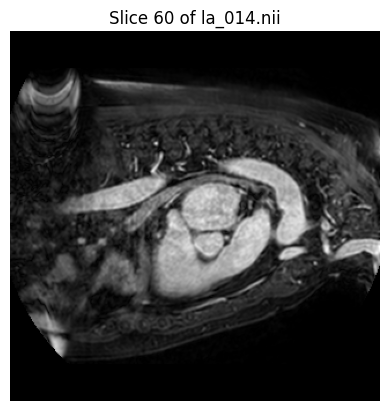

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

# Get the first image file from the list
all_image_files = os.listdir(images_tr_path)
if all_image_files:
    sample_image_file = all_image_files[0]
    full_image_path = os.path.join(images_tr_path, sample_image_file)

    print(f"Loading and displaying a slice from: {sample_image_file}")

    try:
        # Load the NIfTI image
        nifti_img = nib.load(full_image_path)
        img_data = nifti_img.get_fdata()

        # MRI images are 3D, so we display a middle slice
        # Check if the image has at least 3 dimensions before trying to access the third dimension
        if img_data.ndim >= 3:
            mid_slice = img_data.shape[2] // 2
            plt.imshow(img_data[:, :, mid_slice], cmap='gray') # 'gray' colormap is typical for MRI
            plt.title(f"Slice {mid_slice} of {sample_image_file}")
            plt.axis('off')
            plt.show()
        else:
            print(f"Error: Image {sample_image_file} is not 3D, its dimensions are {img_data.ndim}.")
            # If it's 2D, try to display it directly
            plt.imshow(img_data, cmap='gray')
            plt.title(f"Image: {sample_image_file}")
            plt.axis('off')
            plt.show()

    except Exception as e:
        print(f"Error loading or displaying image {sample_image_file}: {e}")
else:
    print(f"No files found in the directory: {images_tr_path}")


In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import random
import time
#PATH PROCESS
import os
import os.path
from pathlib import Path
import glob
from scipy.io import loadmat
import nibabel as nib
#IMAGE PROCESS
from PIL import Image
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from keras.applications.vgg16 import preprocess_input, decode_predictions
from keras.preprocessing import image
from skimage.feature import hessian_matrix, hessian_matrix_eigvals
from scipy.ndimage.filters import convolve
from skimage import data, io, filters
import skimage
from skimage.morphology import convex_hull_image, erosion
from IPython import display
from scipy.ndimage import gaussian_filter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
#SCALER & TRANSFORMATION
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras import regularizers
from sklearn.preprocessing import LabelEncoder
#ACCURACY CONTROL
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
#OPTIMIZER
from keras.optimizers import RMSprop,Adam,Optimizer,Optimizer, SGD
#MODEL LAYERS
from tensorflow.keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization,MaxPooling2D,BatchNormalization,\
                        Permute, TimeDistributed, Bidirectional,GRU, SimpleRNN,\
LSTM, GlobalAveragePooling2D, SeparableConv2D, ZeroPadding2D, Convolution2D, ZeroPadding2D,Reshape, Conv2DTranspose,\
LeakyReLU, GaussianNoise, GlobalMaxPooling2D, ReLU, Input, Concatenate
from keras import models
from keras import layers
import tensorflow as tf
from keras.applications import VGG16,VGG19,inception_v3
from keras import backend as K
from keras.utils import plot_model
from keras.datasets import mnist
import keras
from keras.models import Model
#IGNORING WARNINGS
from warnings import filterwarnings
filterwarnings("ignore",category=DeprecationWarning)
filterwarnings("ignore", category=FutureWarning)
filterwarnings("ignore", category=UserWarning)

/tmp/ipython-input-4112576618.py:23: DeprecationWarning: Please import `convolve` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import convolve


In [ ]:
import os

# Check files inside the downloaded path
print(os.listdir(path))

['imagesTs', 'A large annotated medical image dataset for thedevelopment and evaluation of segmentationalgorithms.pdf', 'labelsTr', 'dataset.json', 'imagesTr']


TypeError: Image data of dtype object cannot be converted to float

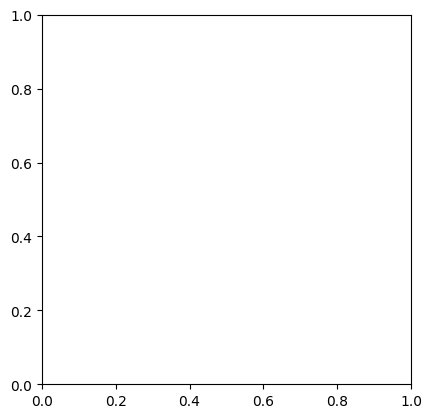

In [ ]:
import matplotlib.pyplot as plt
import cv2

# Kisi bhi ek image ka path uthayein
sample_image_name = os.listdir(path)[0] # Pehli file uthayi
img_path = os.path.join(path, sample_image_name)

# Image read aur show karein
img = cv2.imread(img_path)
plt.imshow(img)
plt.show()

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# 1. Check karein ki andar kaunse folders hain
print("Files/Folders in path:", os.listdir(path))

# 2. Maan lijiye andar 'Train' naam ka folder hai, toh uske andar jao:
# (Agar aapka folder structure alag hai, toh 'Train' ki jagah uska naam likhein)
sub_folder = os.path.join(path, 'Train')

# 3. Ab us folder ki pehli image uthayein
all_images = os.listdir(sub_folder)
img_path = os.path.join(sub_folder, all_images[0])

print(f"Reading image from: {img_path}")

# 4. Image read aur show karein
img = cv2.imread(img_path)

if img is None:
    print("Error: Image load nahi ho payi! Check karein ki path sahi hai ya nahi.")
else:
    # OpenCV BGR format use karta hai, Matplotlib RGB. Convert karna zaroori hai.
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off') # Numbers hatane ke liye
    plt.show()

Files/Folders in path: ['imagesTs', 'A large annotated medical image dataset for thedevelopment and evaluation of segmentationalgorithms.pdf', 'labelsTr', 'dataset.json', 'imagesTr']


FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/adarshsng/heart-mri-image-dataset-left-atrial-segmentation/versions/1/Train'

Reading file: la_014.nii


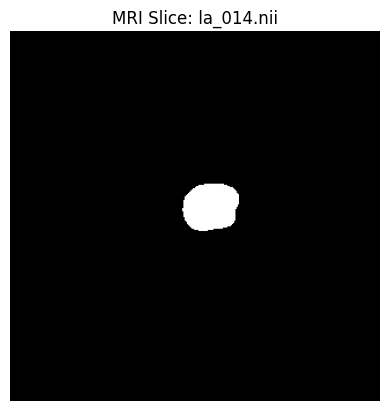

In [ ]:
import os
import nibabel as nib # Medical images ke liye
import matplotlib.pyplot as plt
import numpy as np

# 1. Sahi folder path set karein (Jo aapne list mein dekha)
sub_folder = os.path.join(path, 'labelsTr')

# 2. Pehli file ka naam check karein
all_files = os.listdir(sub_folder)
sample_file = all_files[0]
img_path = os.path.join(sub_folder, sample_file)

print(f"Reading file: {sample_file}")

# 3. Medical Image (NIfTI) load karein
try:
    img_data = nib.load(img_path).get_fdata()

    # MRI 3D hoti hai, isliye hum uska ek 'slice' (jaise middle slice) dekhenge
    mid_slice = img_data.shape[2] // 2

    plt.imshow(img_data[:, :, mid_slice], cmap='bone')
    plt.title(f"MRI Slice: {sample_file}")
    plt.axis('off')
    plt.show()

except Exception as e:
    print("Error: Shayad file format standard image hai. Ye try karein:")
    # Agar image standard format (png/jpg) hai toh:
    import cv2
    img = cv2.imread(img_path)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.show()

In [ ]:
os.listdir(path)

['imagesTs',
 'A large annotated medical image dataset for thedevelopment and evaluation of segmentationalgorithms.pdf',
 'labelsTr',
 'dataset.json',
 'imagesTr']

Total Valid Images: 20
First Image: la_003.nii
First Label: la_003.nii


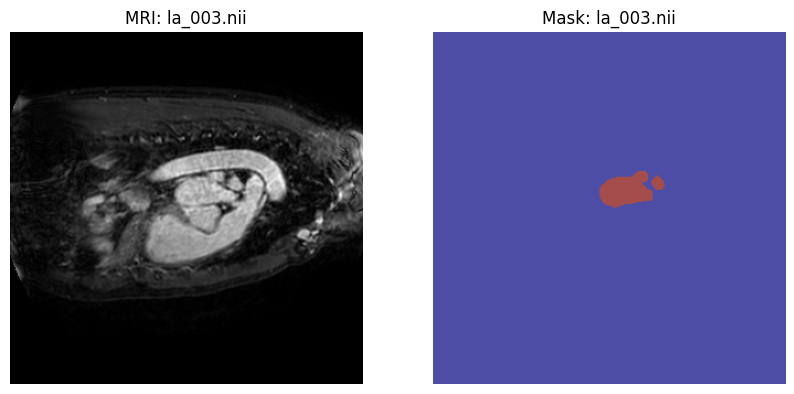

In [ ]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import kagglehub

# 1. Paths set karein
# (Aapka path wahi purana wala hi rahega)
path = "/root/.cache/kagglehub/datasets/adarshsng/heart-mri-image-dataset-left-atrial-segmentation/versions/1"
image_folder = os.path.join(path, 'imagesTr')
label_folder = os.path.join(path, 'labelsTr')

# 2. Files Get karein (STRICT FILTERING ke saath)
# Hum sirf wahi files lenge jo '.nii' ya '.gz' par khatam hoti hain
# Aur jo '._' se shuru NAHI hoti
image_files = sorted([
    f for f in os.listdir(image_folder)
    if not f.startswith('._') and (f.endswith('.nii') or f.endswith('.gz'))
])

label_files = sorted([
    f for f in os.listdir(label_folder)
    if not f.startswith('._') and (f.endswith('.nii') or f.endswith('.gz'))
])

# 3. Check karein ki file list sahi hai ya nahi
if len(image_files) == 0:
    print("Error: Koi bhi valid image file nahi mili! Folder path check karein.")
else:
    # Match check karein (Bahut Zaroori!)
    # Image aur Label ka naam match hona chahiye (Ex: la_003.nii vs la_003.nii)
    print(f"Total Valid Images: {len(image_files)}")
    print(f"First Image: {image_files[0]}")
    print(f"First Label: {label_files[0]}")

    # 4. Load Data (Ab ye crash nahi karega)
    test_img_path = os.path.join(image_folder, image_files[0])
    test_lbl_path = os.path.join(label_folder, label_files[0])

    try:
        img_data = nib.load(test_img_path).get_fdata()
        lbl_data = nib.load(test_lbl_path).get_fdata()

        # 5. Visualize
        mid_slice = img_data.shape[2] // 2

        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(img_data[:, :, mid_slice], cmap='gray')
        plt.title(f"MRI: {image_files[0]}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        # Label ko dikhane ke liye hum mask use karenge
        plt.imshow(lbl_data[:, :, mid_slice], cmap='jet', alpha=0.7)
        plt.title(f"Mask: {label_files[0]}")
        plt.axis('off')

        plt.show()

    except Exception as e:
        print(f"Abhi bhi error aa raha hai: {e}")

In [ ]:
import cv2
import numpy as np
import nibabel as nib

# Lists jisme hum data jama karenge
X_train = [] # Images
Y_train = [] # Masks

# Image ka size (jitna chota, utna fast training)
IMG_SIZE = 128

# Hum wahi file lists use karenge jo pichle step mein banayi thi (image_files, label_files)
# Safety ke liye check kar lete hain ki files match ho rahi hain
print(f"Total files to process: {len(image_files)}")

for i in range(len(image_files)):
    # Progress dikhane ke liye print karein
    print(f"Processing File {i+1}/{len(image_files)}: {image_files[i]}")

    # Path banayein
    img_path = os.path.join(image_folder, image_files[i])
    lbl_path = os.path.join(label_folder, label_files[i])

    # Load 3D Data
    try:
        img_3d = nib.load(img_path).get_fdata()
        lbl_3d = nib.load(lbl_path).get_fdata()
    except:
        continue # Agar koi file corrupt ho toh skip karo

    # Image Normalization (Values ko 0 se 1 ke beech lana zaroori hai)
    # Isse model jaldi seekhta hai
    if np.max(img_3d) > 0: # Divide by zero se bachne ke liye
        img_3d = (img_3d - np.min(img_3d)) / (np.max(img_3d) - np.min(img_3d))

    # SLICING LOOP: Har slice ko check karo
    # img_3d.shape[2] ka matlab hai depth (slices ki ginti)
    for slice_idx in range(img_3d.shape[2]):

        # Ek slice nikalo
        img_slice = img_3d[:, :, slice_idx]
        lbl_slice = lbl_3d[:, :, slice_idx]

        # FILTER: Sirf wahi slice lo jisme Mask (Label) maujood ho
        # Agar mask poora kaala (0) hai, toh use mat lo.
        if np.max(lbl_slice) > 0:

            # Resize karo (128x128)
            img_slice = cv2.resize(img_slice, (IMG_SIZE, IMG_SIZE))
            lbl_slice = cv2.resize(lbl_slice, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

            # List mein add karo
            X_train.append(img_slice)
            Y_train.append(lbl_slice)

# List ko Numpy Array mein badlo (Model ko ye format chahiye)
X_train = np.array(X_train)
Y_train = np.array(Y_train)

# Keras ke liye ek extra dimension add karni padti hai (Channel = 1 for Grayscale)
X_train = np.expand_dims(X_train, axis=-1)
Y_train = np.expand_dims(Y_train, axis=-1)

print("------------------------------------------------")
print("Data Processing Complete!")
print(f"Final Training Images: {X_train.shape}")
print(f"Final Training Masks: {Y_train.shape}")

Total files to process: 20
Processing File 1/20: la_003.nii
Processing File 2/20: la_004.nii
Processing File 3/20: la_005.nii
Processing File 4/20: la_007.nii
Processing File 5/20: la_009.nii
Processing File 6/20: la_010.nii
Processing File 7/20: la_011.nii
Processing File 8/20: la_014.nii
Processing File 9/20: la_016.nii
Processing File 10/20: la_017.nii
Processing File 11/20: la_018.nii
Processing File 12/20: la_019.nii
Processing File 13/20: la_020.nii
Processing File 14/20: la_021.nii
Processing File 15/20: la_022.nii
Processing File 16/20: la_023.nii
Processing File 17/20: la_024.nii
Processing File 18/20: la_026.nii
Processing File 19/20: la_029.nii
Processing File 20/20: la_030.nii
------------------------------------------------
Data Processing Complete!
Final Training Images: (1351, 128, 128, 1)
Final Training Masks: (1351, 128, 128, 1)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate

def simple_unet_model(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS):
    # 1. Input Layer (Darwaza jahan se image andar jayegi)
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    s = inputs

    # --- ENCODER (Left Side: Features Dhoondhna) ---
    # Level 1
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(s)
    p1 = MaxPooling2D((2, 2))(c1) # Image ko aadha kar diya

    # Level 2
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    p2 = MaxPooling2D((2, 2))(c2) # Aur aadha kar diya

    # Level 3 (Bottom/Bridge)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)

    # --- DECODER (Right Side: Mask Banana) ---
    # Level 2 wapis
    u2 = UpSampling2D((2, 2))(c3) # Image ko bada kiya
    u2 = concatenate([u2, c2]) # Puraane features (c2) ko saath mein joda (Skip Connection)
    c4 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u2)

    # Level 1 wapis
    u1 = UpSampling2D((2, 2))(c4) # Aur bada kiya
    u1 = concatenate([u1, c1]) # Puraane features (c1) ko joda
    c5 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u1)

    # Output Layer (Faisla lena: 0 ya 1?)
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c5)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

# Model ko Create karein
model = simple_unet_model(128, 128, 1)

# Model ko Compile karein (Rules set karna)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Summary dekhein
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_3[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 48)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │         17 │ conv2d_4[0][0]    │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 57,921 (226.25 KB)

 Trainable params: 57,921 (226.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training shuru karte hain
history = model.fit(
    X_train,
    Y_train,
    batch_size=16,    # Ek baar mein 16 images dekhega
    epochs=15,        # Poore dataset ko 15 baar padhega
    validation_split=0.1, # 10% data ko alag rakhega test karne ke liye (Cheating nahi karega)
    verbose=1
)

# Model ko save kar lete hain taaki baad mein use kar sakein
model.save('heart_segmentation_model.keras')
print("Training Complete aur Model Save ho gaya!")

Epoch 1/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.9433 - loss: 0.2772 - val_accuracy: 0.9944 - val_loss: 0.0157
Epoch 2/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9932 - loss: 0.0185 - val_accuracy: 0.9944 - val_loss: 0.0116
Epoch 3/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.9933 - loss: 0.0144 - val_accuracy: 0.9944 - val_loss: 0.0099
Epoch 4/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.9931 - loss: 0.0123 - val_accuracy: 0.9944 - val_loss: 0.0103
Epoch 5/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9931 - loss: 0.0112 - val_accuracy: 0.9944 - val_loss: 0.0087
Epoch 6/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.9929 - loss: 0.0104 - val_accuracy: 0.9944 - val_loss: 0.0086
Epoch 7/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.9932 - loss: 0.0095 - val_accuracy: 0.9946 - val_loss: 0.0078
Epoch 8/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.9944 - loss: 0.0090 - val_accuracy: 0.9970 - v

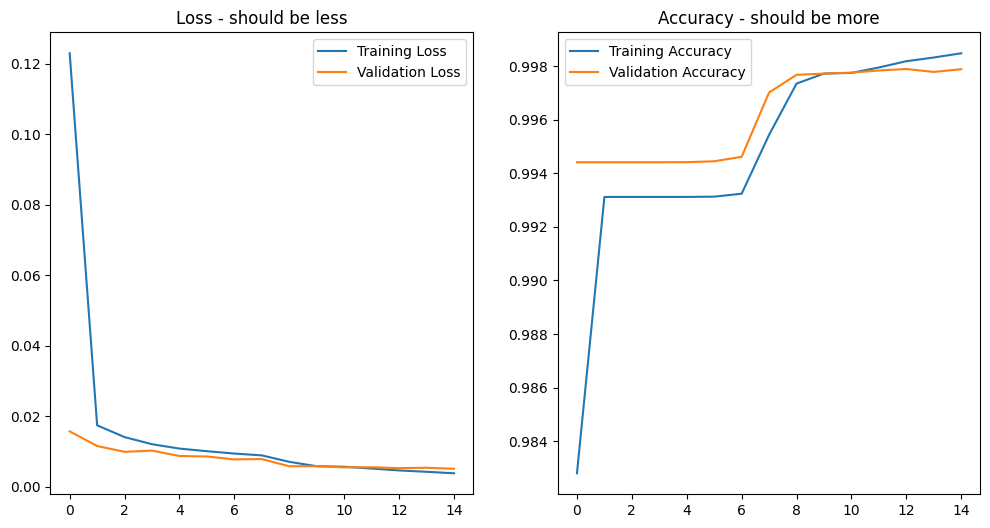

In [ ]:
# Loss ka Graph (Jitna neeche jaye utna accha)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss - should be less')
plt.legend()

# Accuracy ka Graph (Jitna upar jaye utna accha)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy - should be more')
plt.legend()

plt.show()

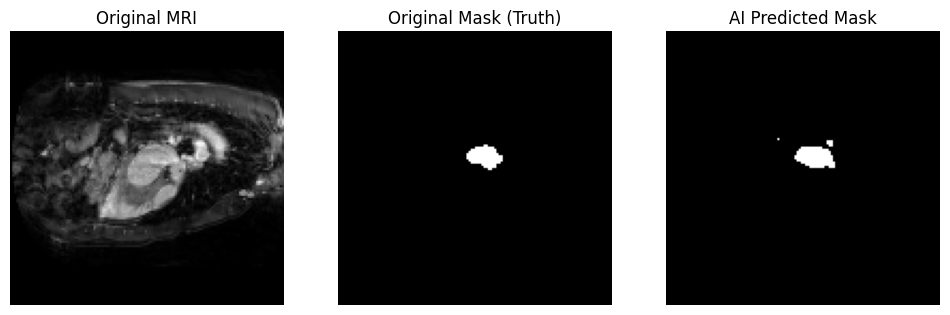

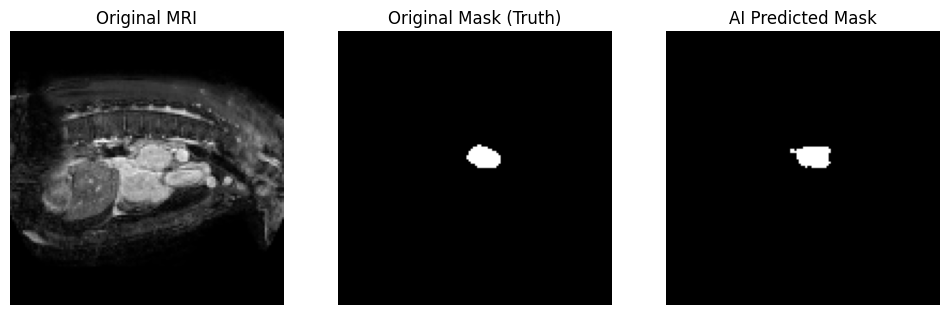

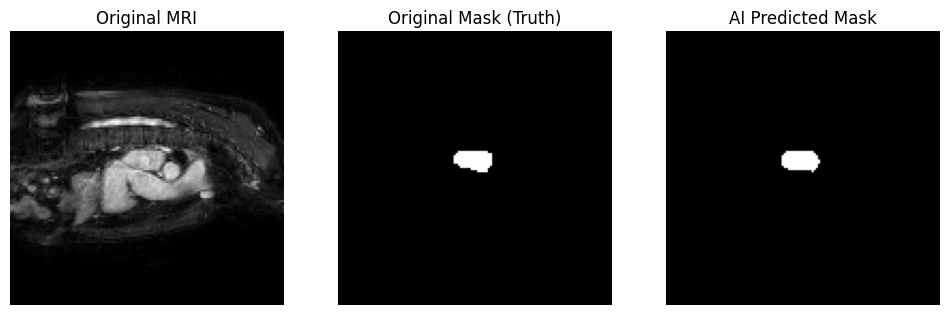

In [ ]:
import random

# Hum check karenge ki model kaisa perform kar raha hai
# Randomly 3 images uthate hain
for i in range(3):
    # Random index choose karo
    idx = random.randint(0, len(X_train) - 1)

    # 1. Original Image aur Mask nikalo
    input_img = X_train[idx]
    true_mask = Y_train[idx]

    # 2. Model se Prediction karwao
    # Model ko batch chahiye hota hai (1, 128, 128, 1), isliye reshape kiya
    pred_mask = model.predict(input_img.reshape(1, 128, 128, 1), verbose=0)

    # 3. Prediction ko Saaf karo (Thresholding)
    # Model probability deta hai (0.1, 0.9 etc). Hum bolenge agar > 0.5 hai toh 1 maano
    pred_mask = (pred_mask > 0.5).astype(np.uint8)

    # --- Plotting (Visual Check) ---
    plt.figure(figsize=(12, 4))

    # Original MRI
    plt.subplot(1, 3, 1)
    plt.imshow(input_img.squeeze(), cmap='gray')
    plt.title("Original MRI")
    plt.axis('off')

    # Asli Mask (Doctor wala)
    plt.subplot(1, 3, 2)
    plt.imshow(true_mask.squeeze(), cmap='gray')
    plt.title("Original Mask (Truth)")
    plt.axis('off')

    # AI ka Banaya Mask
    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask.squeeze(0).squeeze(), cmap='gray') # Extra dimensions hatane ke liye squeeze
    plt.title("AI Predicted Mask")
    plt.axis('off')

    plt.show()

In [ ]:
from google.colab import files

# 1. Pehle sure karein ki model Colab me save hai
model.save('heart_segmentation_model.keras')

# 2. Ab use download karein
files.download('heart_segmentation_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>